In [2]:
from pathlib import Path
import cv2

# Resolve the project root from src/test.ipynb
project_root = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()

# Support both "image" and "images" folder names
candidate_dirs = [project_root / "image", project_root / "images"]
image_dir = next((d for d in candidate_dirs if d.exists()), None)

if image_dir is None:
    raise FileNotFoundError("Could not find an 'image' or 'images' folder in the project root.")

# Common image extensions
extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
image_paths = sorted([p for p in image_dir.iterdir() if p.suffix.lower() in extensions])

if not image_paths:
    raise FileNotFoundError(f"No image files found in: {image_dir}")

images = {}
for path in image_paths:
    img = cv2.imread(str(path))
    if img is not None:
        images[path.name] = img

print(f"Loaded {len(images)} image(s) from {image_dir}")
print("Files:", list(images.keys()))

Loaded 10 image(s) from c:\Users\admin\Coding\warisa-students\SILSUPA\images
Files: ['R3DR_300x.jpg', 'R3LC_1000x.jpg', 'R3LC_300x.jpg', 'R3LC_700x.jpg', 'R4DR_1000x.jpg', 'R4DR_300x.jpg', 'R4DR_700x.jpg', 'R4LC_1000x.jpg', 'R4LC_300x.jpg', 'R4LC_700x.jpg']


Pore size summary (diameter in pixels):
- R3DR_300x.jpg: porosity=0.406, n=2526204, mean=4.22, median=3.49, max=17.74
- R3LC_1000x.jpg: porosity=0.407, n=2534862, mean=8.04, median=7.00, max=31.30
- R3LC_300x.jpg: porosity=0.459, n=2855822, mean=6.32, median=5.47, max=34.96
- R3LC_700x.jpg: porosity=0.419, n=2608481, mean=6.67, median=5.86, max=26.17
- R4DR_1000x.jpg: porosity=0.470, n=2924494, mean=10.12, median=9.17, max=38.12
- R4DR_300x.jpg: porosity=0.490, n=3048189, mean=286.32, median=479.88, max=627.63
- R4DR_700x.jpg: porosity=0.346, n=2154649, mean=271.16, median=410.78, max=410.78
- R4LC_1000x.jpg: porosity=0.443, n=2758752, mean=7.17, median=5.66, max=37.47
- R4LC_300x.jpg: porosity=0.441, n=2745950, mean=3.72, median=3.34, max=18.11
- R4LC_700x.jpg: porosity=0.491, n=3051789, mean=5.51, median=4.85, max=27.20


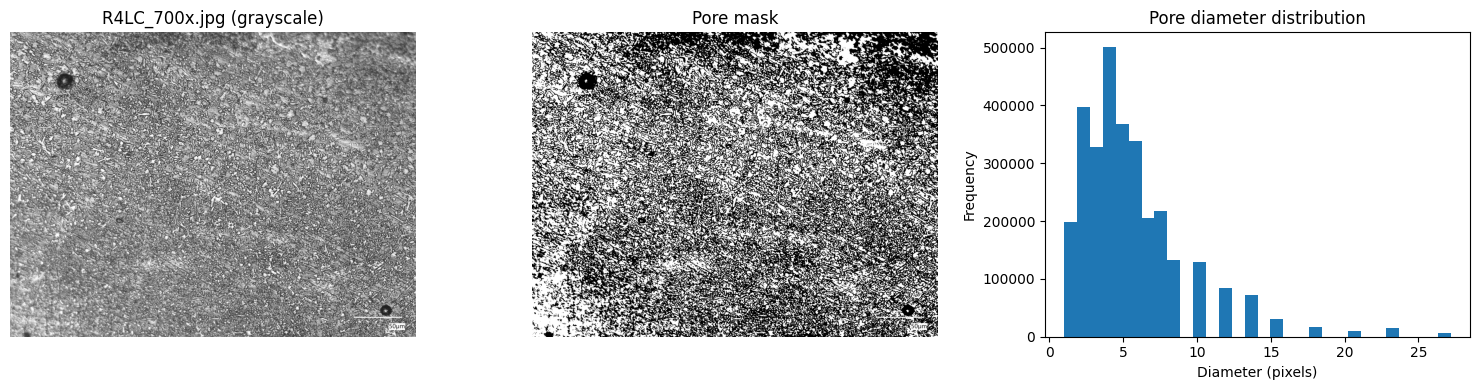

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import porespy as ps

if not images:
    raise ValueError("No images found. Run the image-loading cell first.")

results = []
last_preview = None

for name, img_bgr in images.items():
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY) if img_bgr.ndim == 3 else img_bgr.copy()

    # Otsu threshold; choose the minority phase as pores.
    threshold, _ = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    pores_dark = gray < threshold
    pores_bright = gray > threshold
    pore_mask = pores_dark if pores_dark.mean() <= pores_bright.mean() else pores_bright

    lt = ps.filters.local_thickness(pore_mask)
    pore_diameters = lt[pore_mask]
    pore_diameters = pore_diameters[pore_diameters > 0]

    if pore_diameters.size == 0:
        results.append({
            "image": name,
            "porosity": float(pore_mask.mean()),
            "count": 0,
            "mean_diameter_px": np.nan,
            "median_diameter_px": np.nan,
            "max_diameter_px": np.nan,
        })
        continue

    results.append({
        "image": name,
        "porosity": float(pore_mask.mean()),
        "count": int(pore_diameters.size),
        "mean_diameter_px": float(np.mean(pore_diameters)),
        "median_diameter_px": float(np.median(pore_diameters)),
        "max_diameter_px": float(np.max(pore_diameters)),
    })

    last_preview = (name, gray, pore_mask, pore_diameters)

print("Pore size summary (diameter in pixels):")
for row in results:
    print(
        f"- {row['image']}: porosity={row['porosity']:.3f}, "
        f"n={row['count']}, mean={row['mean_diameter_px']:.2f}, "
        f"median={row['median_diameter_px']:.2f}, max={row['max_diameter_px']:.2f}"
    )

# Preview the last processed image and its pore-size histogram.
if last_preview is not None:
    name, gray, pore_mask, pore_diameters = last_preview
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(gray, cmap="gray")
    axes[0].set_title(f"{name} (grayscale)")
    axes[0].axis("off")

    axes[1].imshow(pore_mask, cmap="gray")
    axes[1].set_title("Pore mask")
    axes[1].axis("off")

    axes[2].hist(pore_diameters, bins=30)
    axes[2].set_title("Pore diameter distribution")
    axes[2].set_xlabel("Diameter (pixels)")
    axes[2].set_ylabel("Frequency")
    plt.tight_layout()
    plt.show()